<a href="https://colab.research.google.com/github/aysearyavilgenoglu/ESTATEIQ/blob/main/IAT461_LAB05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Summary: Introduction to the walkthrough lab on Clustering (K-Means, DBSCAN, HDBSCAN) and Dimensionality Reduction (PCA, t-SNE, UMAP). The goal is to analyze a dataset of 296 Metro Vancouver businesses to help an investor choose a location and category balancing revenue with community impact.

Summary: Section 0 setup guide, recommending installation of specialist libraries `hdbscan` and `umap-learn` before starting.

In [19]:
# Import core and specialist libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Preprocessing, metrics, clustering, PCA, t-SNE, and UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
import hdbscan
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Configure plotting styles and disable warnings
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


Summary: Section 1 loading and exploring the GeoJSON business dataset, converting it into a flattened pandas DataFrame for simpler processing.

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import json

with open("/content/drive/MyDrive/IAT461_LAB05/business_locations.geojson") as f:
    geojson_data = json.load(f)

print(f"Total features: {len(geojson_data['features'])}")
print(json.dumps(geojson_data['features'][0], indent=2))

Total features: 296
{
  "type": "Feature",
  "geometry": {
    "type": "Point",
    "coordinates": [
      -122.78442,
      49.20555
    ]
  },
  "properties": {
    "ID": 1,
    "Neighborhood": "Riverside Commons",
    "Category": "Hospitality",
    "Subcategory": "Theatre",
    "Floor_Area_sqm": 465,
    "Daily_Foot_Traffic": 1995,
    "Community_Impact_Score": 79,
    "Annual_Revenue_k": 1037
  }
}


In [22]:
rows = []
for feature in geojson_data['features']:
    props = feature['properties']
    longitude, latitude = feature['geometry']['coordinates']
    row = {**props, 'Longitude': longitude, 'Latitude': latitude}
    rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(296, 10)


,ID,Neighborhood,Category,Subcategory,Floor_Area_sqm,Daily_Foot_Traffic,Community_Impact_Score,Annual_Revenue_k,Longitude,Latitude
0,1,Riverside Commons,Hospitality,Theatre,465,1995,79,1037,-122.78442,49.20555
1,2,Riverside Commons,Hospitality,Restaurant,222,1891,66,233,-122.78864,49.20323
2,3,Tech Corridor,Office,Software Firm,596,665,47,3165,-122.91274,49.15874
3,4,Riverside Commons,Hospitality,Theatre,166,1193,92,231,-122.79028,49.20023
4,5,Outer Industrial Park,Industrial,Self-Storage,10460,415,13,4487,-122.70319,49.24512


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      296 non-null    int64  
 1   Neighborhood            296 non-null    object 
 2   Category                296 non-null    object 
 3   Subcategory             296 non-null    object 
 4   Floor_Area_sqm          296 non-null    int64  
 5   Daily_Foot_Traffic      296 non-null    int64  
 6   Community_Impact_Score  296 non-null    int64  
 7   Annual_Revenue_k        296 non-null    int64  
 8   Longitude               296 non-null    float64
 9   Latitude                296 non-null    float64
dtypes: float64(2), int64(5), object(3)
memory usage: 23.3+ KB


In [24]:
df.describe()

,ID,Floor_Area_sqm,Daily_Foot_Traffic,Community_Impact_Score,Annual_Revenue_k,Longitude,Latitude
count,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
mean,148.500000,4396.722973,1106.621622,54.111486,3697.841216,-122.809990,49.195751
std,85.592056,7245.715469,741.744219,26.801551,4652.227233,0.077615,0.031342
min,1.000000,70.000000,15.000000,0.000000,88.000000,-122.966950,49.130680
25%,74.750000,244.750000,422.250000,31.000000,441.000000,-122.878000,49.168255
50%,148.500000,468.500000,815.000000,58.500000,1468.000000,-122.823215,49.189095
75%,222.250000,3287.000000,1777.250000,78.000000,5897.000000,-122.727007,49.217618
max,296.000000,24863.000000,2639.000000,100.000000,33994.000000,-122.651890,49.262650


Summary: Observes scaling differences in raw features (e.g. floor area variance vs. impact score) and introduces visualization of data distribution.

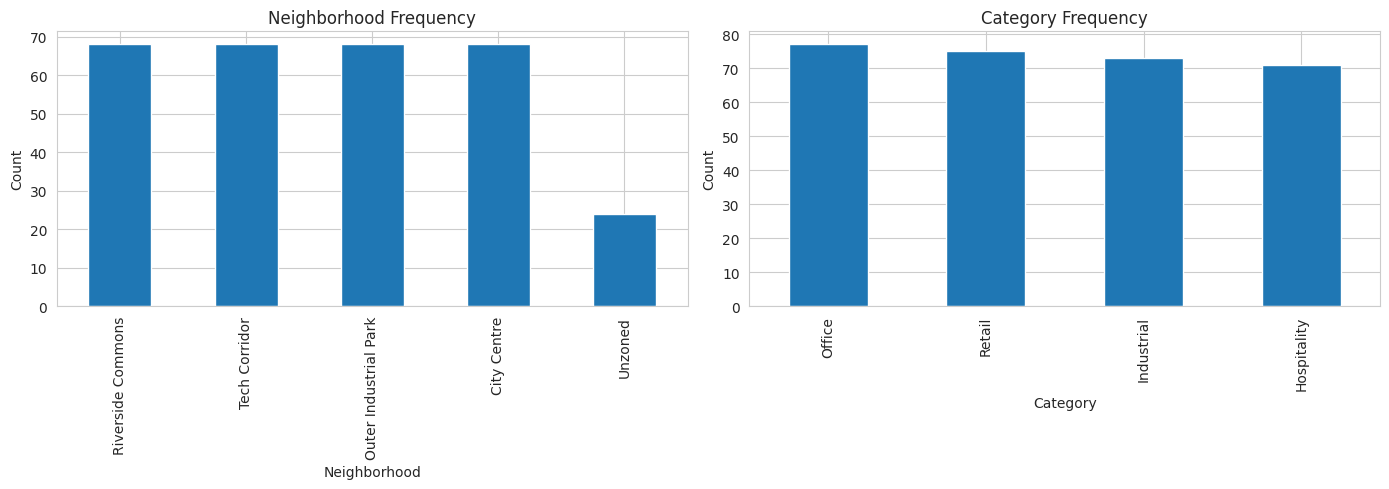

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Neighborhood'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Neighborhood Frequency')
axes[0].set_xlabel('Neighborhood')
axes[0].set_ylabel('Count')

df['Category'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Category Frequency')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

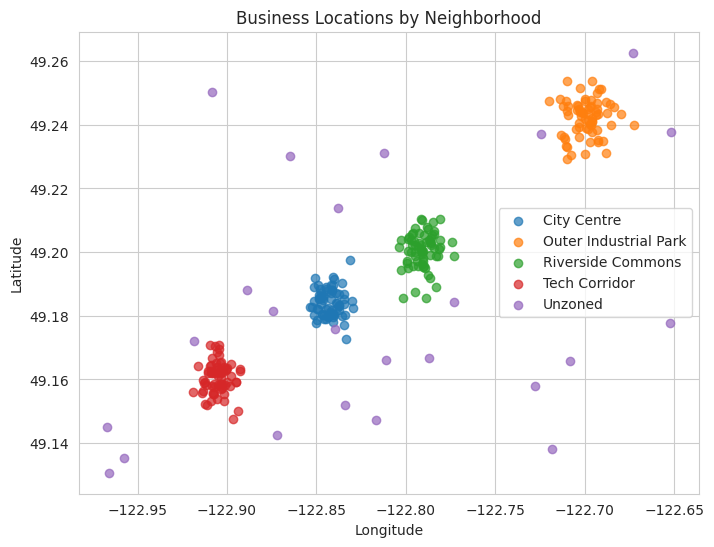

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

for neighborhood, group in df.groupby('Neighborhood'):
    ax.scatter(group['Longitude'], group['Latitude'], label=neighborhood, alpha=0.7)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Business Locations by Neighborhood')
ax.legend()
plt.show()

Summary: Analyzes ground truth spatial clusters, noting four dense neighborhoods and scattered noise/outlier points.

Summary: Part 1 clustering introduction, explaining unsupervised learning and partitioning coordinate data.

In [27]:
geo_features = df[['Longitude', 'Latitude']]
scaler_geo = StandardScaler()
geo_scaled = scaler_geo.fit_transform(geo_features)

print("Before scaling:")
print(geo_features.mean())
print(geo_features.std())

print("\nAfter scaling:")
print(geo_scaled.mean(axis=0))
print(geo_scaled.std(axis=0))

Before scaling:
Longitude   -122.809990
Latitude      49.195751
dtype: float64
Longitude    0.077615
Latitude     0.031342
dtype: float64

After scaling:
[-3.59352188e-14  5.75395587e-14]
[1. 1.]


Summary: Explains K-Means algorithm steps, characteristics, and limitations in forcing outliers into clusters.

In [28]:
def kmeans_step_by_step(X, k, n_iterations, seed):
    rng = np.random.RandomState(seed)

    initial_idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[initial_idx]

    history = [centroids.copy()]

    for iteration in range(n_iterations):

        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        centroids = new_centroids
        history.append(centroids.copy())

    return history, labels

history, labels = kmeans_step_by_step(geo_scaled, k=4, n_iterations=5, seed=RANDOM_STATE)
print(f"Length of centroid history: {len(history)}")

Length of centroid history: 6


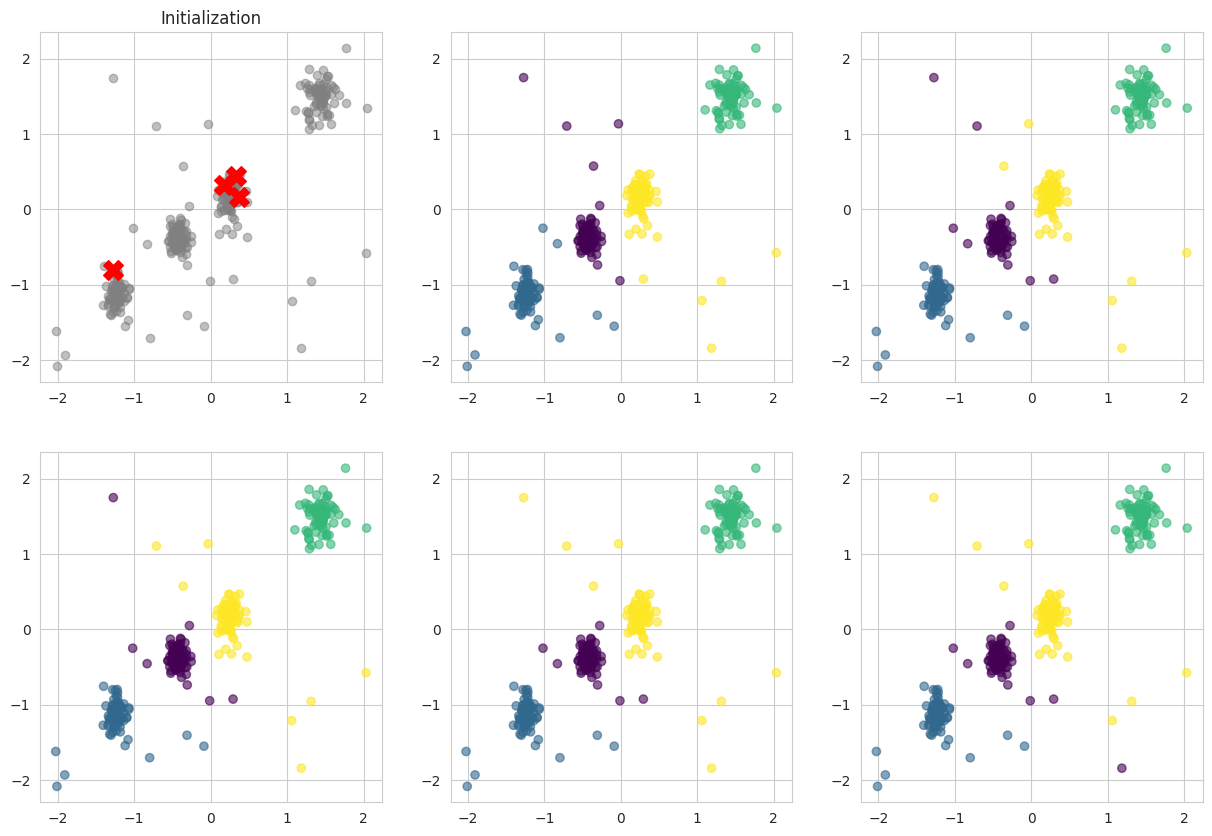

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i == 0:
        ax.scatter(geo_scaled[:, 0], geo_scaled[:, 1], alpha=0.5, color='gray')
        ax.scatter(history[0][:, 0], history[0][:, 1], color='red', marker='X', s=200, label='Initial Centroids')
        ax.set_title('Initialization')
    else:
        centroids = history[i]
        distances = np.linalg.norm(geo_scaled[:, np.newaxis] - centroids, axis=2)
        labels_i = np.argmin(distances, axis=1)

        ax.scatter(geo_scaled[:, 0], geo_scaled[:, 1], c=labels_i, cmap='viridis', alpha=0.6)

Summary: Observes K-Means convergence behavior and introduces elbow and silhouette metrics for selecting the cluster count k.

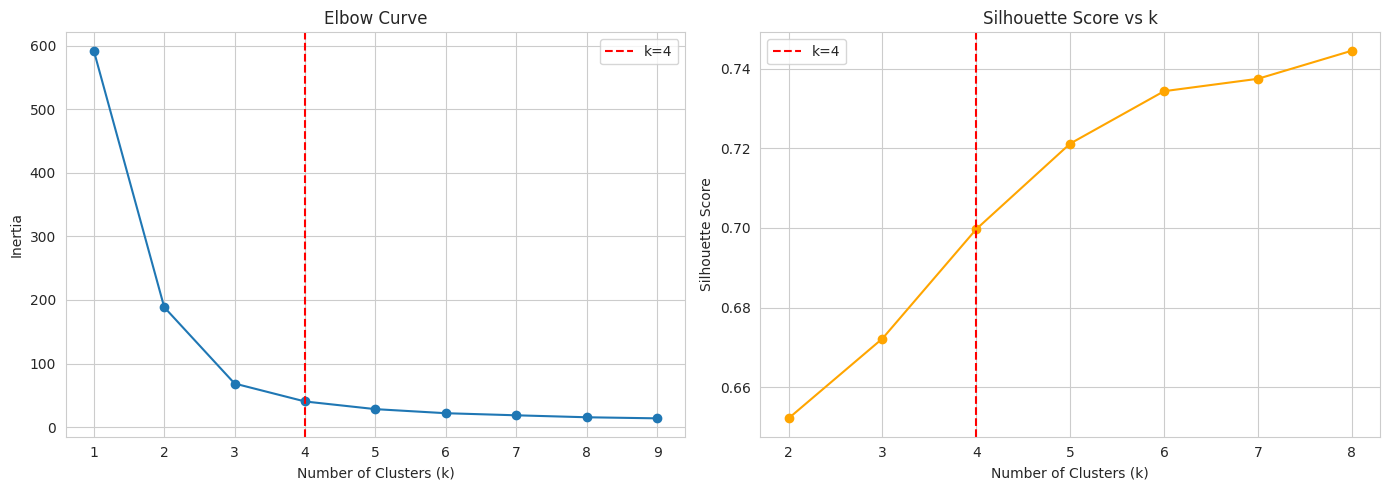

In [30]:
inertias = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(geo_scaled)
    inertias.append(kmeans.inertia_)

silhouette_scores = {}
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = kmeans.fit_predict(geo_scaled)
    score = silhouette_score(geo_scaled, labels_k)
    silhouette_scores[k] = score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 10), inertias, marker='o')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', label='k=4')
axes[0].legend()

axes[1].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', color='orange')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='red', linestyle='--', label='k=4')
axes[1].legend()

plt.tight_layout()
plt.show()

Summary: Evaluates elbow and silhouette diagnostic plots, identifying k=4 as the optimal choice.

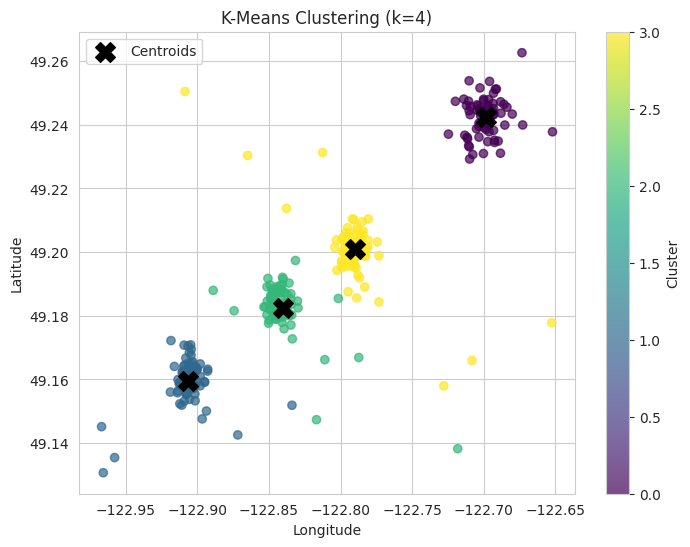

In [31]:
kmeans_final = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(geo_scaled)

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(df['Longitude'], df['Latitude'], c=df['KMeans_Cluster'], cmap='viridis', alpha=0.7)

centroids_original = scaler_geo.inverse_transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_original[:, 0], centroids_original[:, 1], color='black', marker='X', s=200, label='Centroids')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('K-Means Clustering (k=4)')
ax.legend()
plt.colorbar(scatter, label='Cluster')
plt.show()

Summary: Asks how K-Means partitioned unzoned noise points.

In [32]:
pd.crosstab(df['KMeans_Cluster'], df['Neighborhood'])

Neighborhood,City Centre,Outer Industrial Park,Riverside Commons,Tech Corridor,Unzoned
KMeans_Cluster,,,,,
0,0,68,0,0,3
1,0,0,0,68,6
2,68,0,1,0,7
3,0,0,67,0,8


Summary: Notes K-Means failure in handling noise/outliers, and motivates density-based spatial clustering.

Summary: Explains DBSCAN core/border/noise definitions, algorithm flow, and k-distance plot for choosing eps.

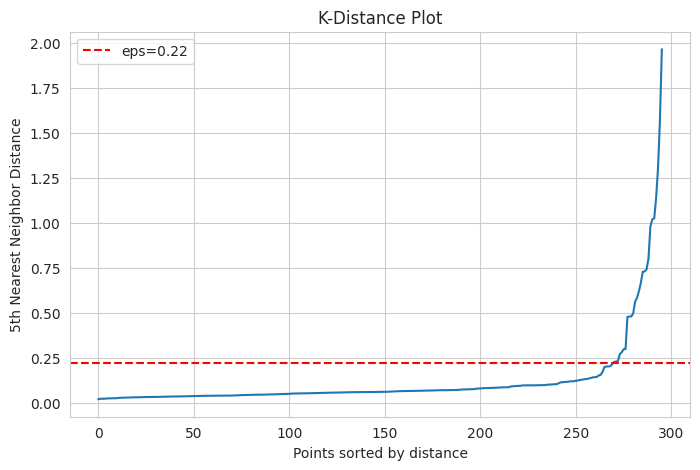

In [33]:
min_samples = 5
neighbors_model = NearestNeighbors(n_neighbors=min_samples)
neighbors_model.fit(geo_scaled)
distances, indices = neighbors_model.kneighbors(geo_scaled)

k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_distances)
ax.axhline(y=0.22, color='red', linestyle='--', label='eps=0.22')
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel('5th Nearest Neighbor Distance')
ax.set_title('K-Distance Plot')
ax.legend()
plt.show()

Summary: Identifies eps=0.22 at the knee of the k-distance plot.

In [34]:
dbscan = DBSCAN(eps=0.22, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(geo_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise = (df['DBSCAN_Cluster'] == -1).sum()

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points flagged: {n_noise}")

Number of clusters found: 4
Number of noise points flagged: 20


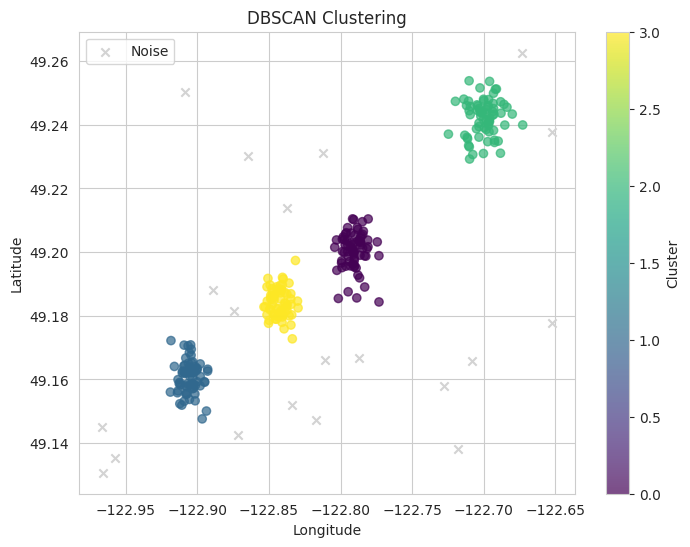

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

clustered = df[df['DBSCAN_Cluster'] != -1]
noise = df[df['DBSCAN_Cluster'] == -1]

scatter = ax.scatter(clustered['Longitude'], clustered['Latitude'], c=clustered['DBSCAN_Cluster'], cmap='viridis', alpha=0.7)
ax.scatter(noise['Longitude'], noise['Latitude'], color='lightgray', marker='x', label='Noise')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('DBSCAN Clustering')
ax.legend()
plt.colorbar(scatter, label='Cluster')
plt.show()

In [36]:
pd.crosstab(df['DBSCAN_Cluster'], df['Neighborhood'])

Neighborhood,City Centre,Outer Industrial Park,Riverside Commons,Tech Corridor,Unzoned
DBSCAN_Cluster,,,,,
-1,0,0,0,0,20
0,0,0,68,0,1
1,0,0,0,68,1
2,0,68,0,0,1
3,68,0,0,0,1


Summary: Compares DBSCAN performance to K-Means, highlighting its success with noise but noting uniform density limits. Introduces HDBSCAN.

Summary: Explains HDBSCAN conceptual steps (reachability distance, minimum spanning tree, hierarchy, and condensed tree) which remove the need for a global eps.

In [37]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
df['HDBSCAN_Cluster'] = clusterer.fit_predict(geo_scaled)
df['HDBSCAN_Probability'] = clusterer.probabilities_

n_clusters_hdb = len(set(df['HDBSCAN_Cluster'])) - (1 if -1 in df['HDBSCAN_Cluster'].values else 0)
n_noise_hdb = (df['HDBSCAN_Cluster'] == -1).sum()

print(f"Number of clusters found: {n_clusters_hdb}")
print(f"Number of noise points flagged: {n_noise_hdb}")

Number of clusters found: 4
Number of noise points flagged: 17


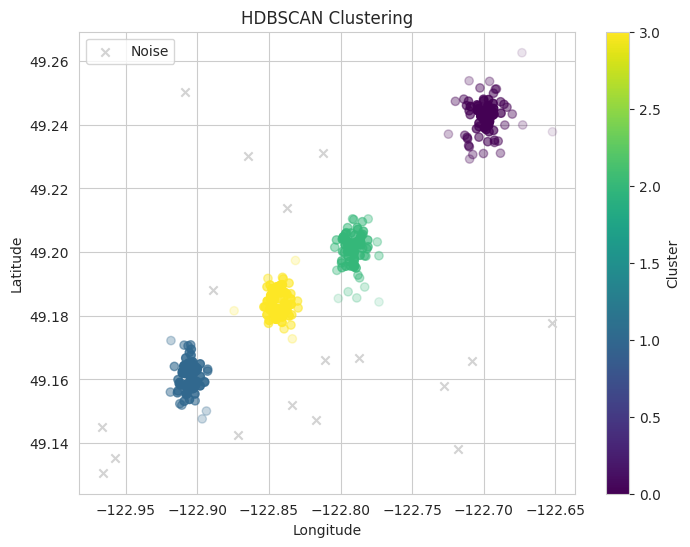

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

clustered = df[df['HDBSCAN_Cluster'] != -1]
noise = df[df['HDBSCAN_Cluster'] == -1]

scatter = ax.scatter(clustered['Longitude'], clustered['Latitude'],
                      c=clustered['HDBSCAN_Cluster'], cmap='viridis',
                      alpha=clustered['HDBSCAN_Probability'])

ax.scatter(noise['Longitude'], noise['Latitude'], color='lightgray', marker='x', label='Noise')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('HDBSCAN Clustering')
ax.legend()
plt.colorbar(scatter, label='Cluster')
plt.show()

Summary: Explains the condensed tree diagram visualizing cluster splits and branch stability.

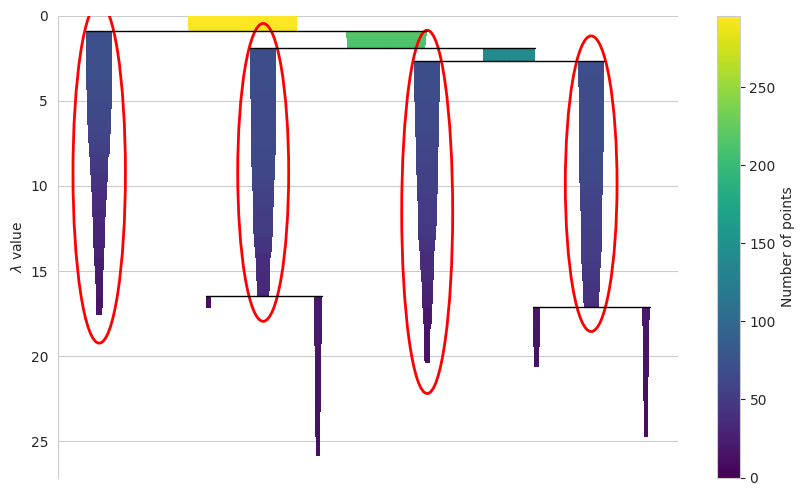

In [39]:
plt.figure(figsize=(10, 6))
clusterer.condensed_tree_.plot(select_clusters=True)
plt.show()


In [40]:
pd.crosstab(df['HDBSCAN_Cluster'], df['Neighborhood'])

Neighborhood,City Centre,Outer Industrial Park,Riverside Commons,Tech Corridor,Unzoned
HDBSCAN_Cluster,,,,,
-1,0,0,0,0,17
0,0,68,0,0,3
1,0,0,0,68,1
2,0,0,68,0,1
3,68,0,0,0,2


Summary: Evaluates HDBSCAN results, showing similar performance to DBSCAN but explaining its advantage for variable densities.

Summary: Provides a comparison table between K-Means, DBSCAN, and HDBSCAN across parameters, noise, shapes, and speed.

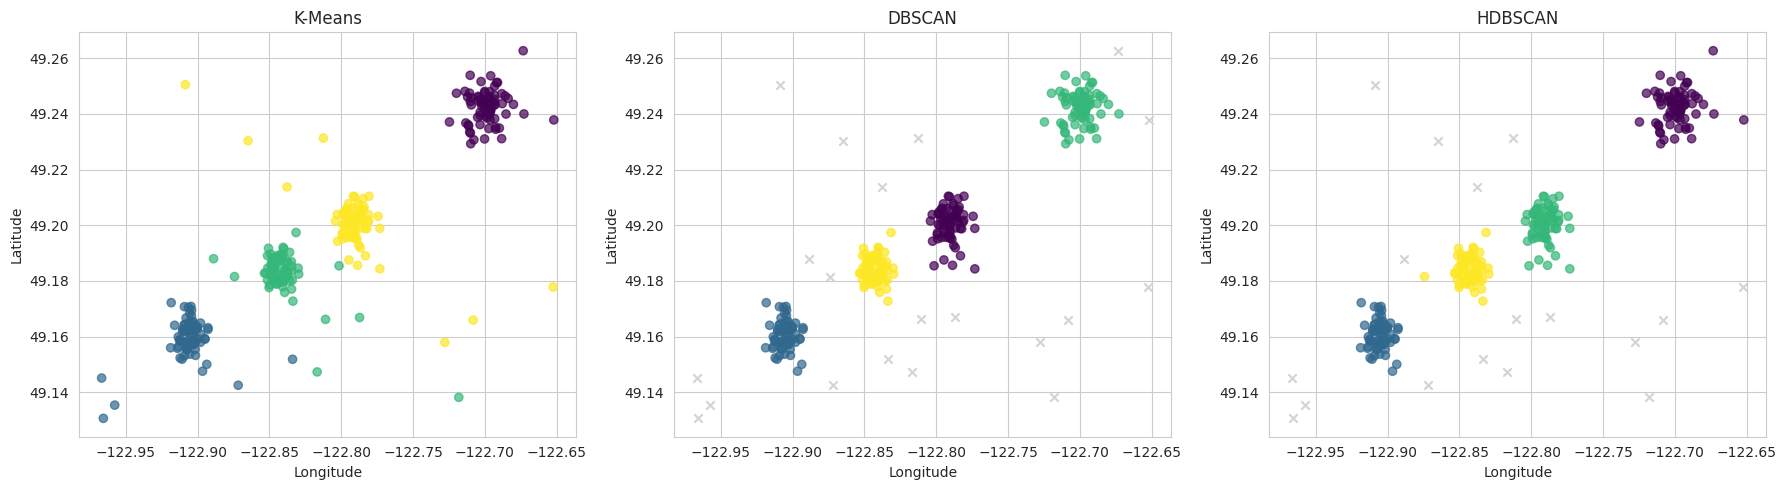

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(df['Longitude'], df['Latitude'], c=df['KMeans_Cluster'], cmap='viridis', alpha=0.7)
axes[0].set_title('K-Means')

# DBSCAN
clustered_db = df[df['DBSCAN_Cluster'] != -1]
noise_db = df[df['DBSCAN_Cluster'] == -1]
axes[1].scatter(clustered_db['Longitude'], clustered_db['Latitude'], c=clustered_db['DBSCAN_Cluster'], cmap='viridis', alpha=0.7)
axes[1].scatter(noise_db['Longitude'], noise_db['Latitude'], color='lightgray', marker='x')
axes[1].set_title('DBSCAN')

# HDBSCAN
clustered_hdb = df[df['HDBSCAN_Cluster'] != -1]
noise_hdb = df[df['HDBSCAN_Cluster'] == -1]
axes[2].scatter(clustered_hdb['Longitude'], clustered_hdb['Latitude'], c=clustered_hdb['HDBSCAN_Cluster'], cmap='viridis', alpha=0.7)
axes[2].scatter(noise_hdb['Longitude'], noise_hdb['Latitude'], color='lightgray', marker='x')
axes[2].set_title('HDBSCAN')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

Summary: Recommends HDBSCAN (with noise filtering) as the most reliable geographic segmentation for the investor.

Summary: Part 2 dimensionality reduction introduction. Highlights the need to compress 4 numeric business attributes into 2 dimensions for visual inspection.

In [42]:
feature_cols = ['Floor_Area_sqm', 'Daily_Foot_Traffic', 'Community_Impact_Score', 'Annual_Revenue_k']
df[feature_cols].describe()

,Floor_Area_sqm,Daily_Foot_Traffic,Community_Impact_Score,Annual_Revenue_k
count,296.000000,296.000000,296.000000,296.000000
mean,4396.722973,1106.621622,54.111486,3697.841216
std,7245.715469,741.744219,26.801551,4652.227233
min,70.000000,15.000000,0.000000,88.000000
25%,244.750000,422.250000,31.000000,441.000000
50%,468.500000,815.000000,58.500000,1468.000000
75%,3287.000000,1777.250000,78.000000,5897.000000
max,24863.000000,2639.000000,100.000000,33994.000000


Summary: Discusses scale differences (variance) across features, making standardization a mandatory step to prevent dominating features.

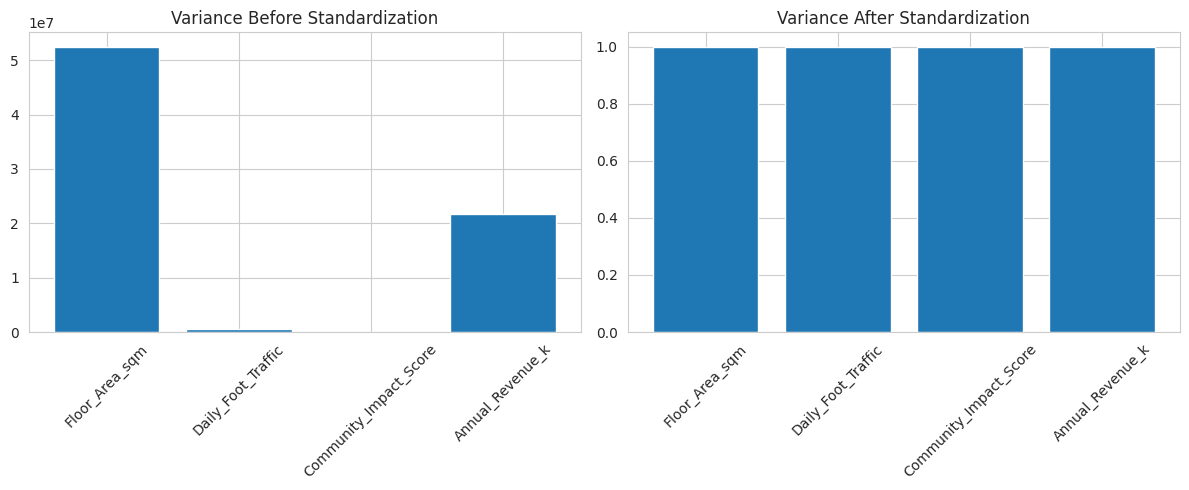

In [43]:
X_raw = df[feature_cols].values
scaler_features = StandardScaler()
X_scaled = scaler_features.fit_transform(X_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(feature_cols, df[feature_cols].var())
axes[0].set_title('Variance Before Standardization')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(feature_cols, X_scaled.var(axis=0))
axes[1].set_title('Variance After Standardization')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Summary: Notes equalized variance after scaling and introduces PCA.

Summary: Explains PCA mathematical steps (covariance, eigenvalues, sorting, and projection).

In [44]:
X_pair = df[['Floor_Area_sqm', 'Annual_Revenue_k']].values
X_pair_scaled = StandardScaler().fit_transform(X_pair)

cov_matrix = np.cov(X_pair_scaled.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print("Covariance matrix:\n", cov_matrix)
print("\nEigenvalues:", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

Covariance matrix:
 [[1.00338983 0.78022002]
 [0.78022002 1.00338983]]

Eigenvalues: [1.78360985 0.22316981]

Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


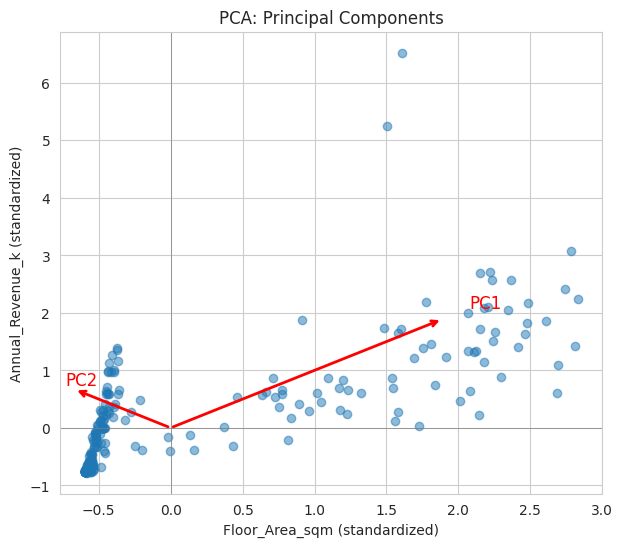

In [45]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pair_scaled[:, 0], X_pair_scaled[:, 1], alpha=0.5)

origin = np.array([0, 0])
for i in range(2):
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2
    ax.annotate('', xy=vec, xytext=origin,
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text(vec[0]*1.1, vec[1]*1.1, f'PC{i+1}', color='red', fontsize=12)

ax.set_xlabel('Floor_Area_sqm (standardized)')
ax.set_ylabel('Annual_Revenue_k (standardized)')
ax.set_title('PCA: Principal Components')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
plt.show()

Summary: Notes that PC1 captures the shared diagonal trend of correlation between floor area and revenue.

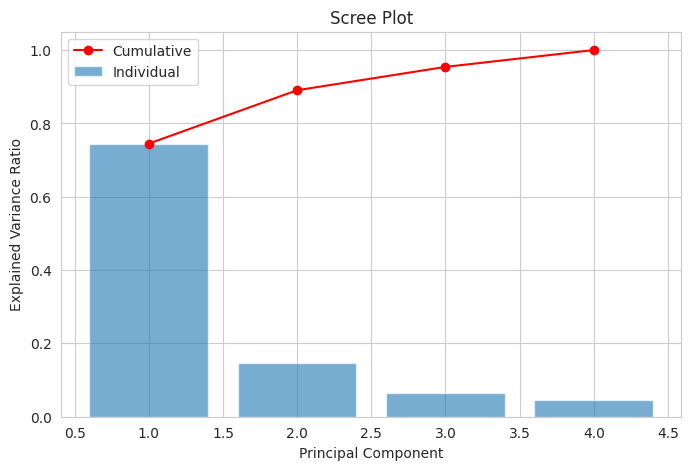

Explained variance ratio: [0.74478182 0.14562673 0.06365091 0.04594054]
Cumulative variance ratio: [0.74478182 0.89040855 0.95405946 1.        ]


In [46]:
pca = PCA()
principal_components = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, len(explained)+1), explained, alpha=0.6, label='Individual')
ax.plot(range(1, len(cumulative)+1), cumulative, marker='o', color='red', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot')
ax.legend()
plt.show()

print("Explained variance ratio:", explained)
print("Cumulative variance ratio:", cumulative)

Summary: Reviews scree plot showing PC1 and PC2 capture ~89% of the total variance.

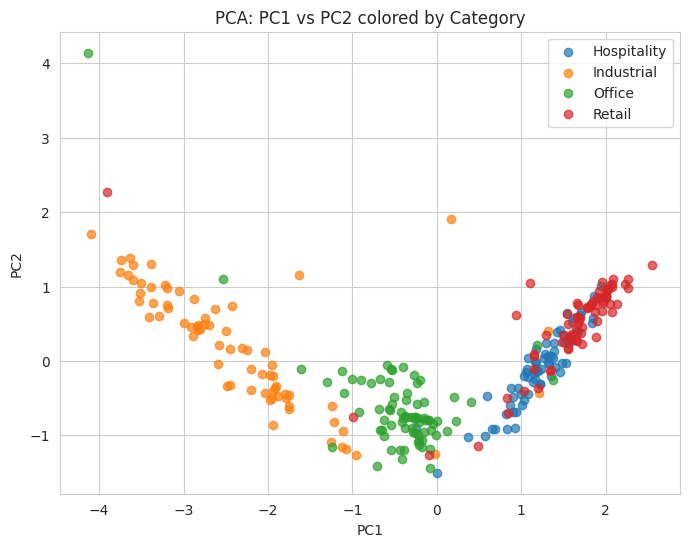

In [47]:
df['PCA1'] = principal_components[:, 0]
df['PCA2'] = principal_components[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
for category, group in df.groupby('Category'):
    ax.scatter(group['PCA1'], group['PCA2'], label=category, alpha=0.7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA: PC1 vs PC2 colored by Category')
ax.legend()
plt.show()

Summary: Highlights PCA's superpower of interpretable loading axes.

In [48]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(len(feature_cols))]
)
print(loadings)

                             PC1       PC2       PC3       PC4
Floor_Area_sqm         -0.505362  0.476982 -0.404808  0.594330
Daily_Foot_Traffic      0.468585  0.696064 -0.361555 -0.406450
Community_Impact_Score  0.522933  0.277687  0.545397  0.593273
Annual_Revenue_k       -0.501576  0.459209  0.638710 -0.359997


Summary: Interprets PC1 loading values, showing it models the exact trade-off between scale/revenue and foot-traffic/community impact.

Summary: Explains t-SNE probability maps, t-distribution projection, KL-divergence minimization, and local neighborhood focus.

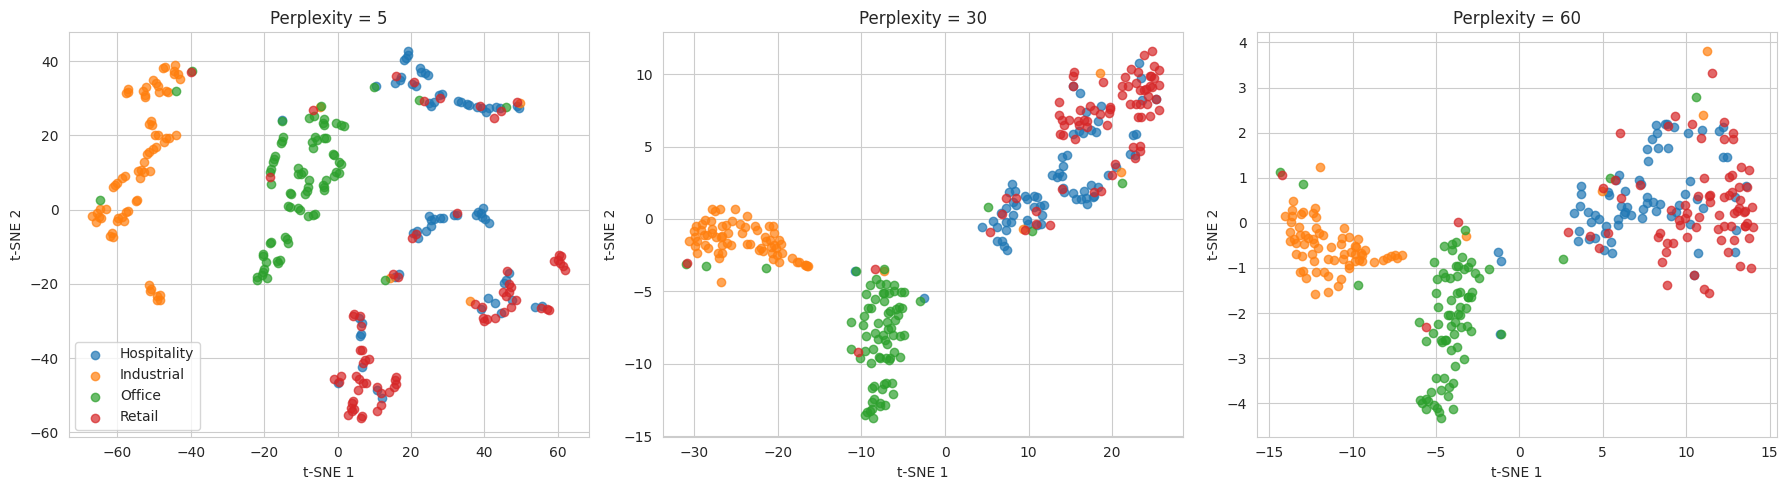

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, perplexity in enumerate([5, 30, 60]):
    tsne = TSNE(n_components=2, perplexity=perplexity, init='pca', random_state=RANDOM_STATE)
    embedding = tsne.fit_transform(X_scaled)

    for category, idx in df.groupby('Category').groups.items():
        mask = df.index.isin(idx)
        axes[i].scatter(embedding[mask, 0], embedding[mask, 1], label=category, alpha=0.7)

    axes[i].set_title(f'Perplexity = {perplexity}')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')

axes[0].legend()
plt.tight_layout()
plt.show()

Summary: Evaluates perplexity parameter influence and notes t-SNE does not preserve global distances.

Summary: Steps of the UMAP algorithm. Explains k-nearest neighbors graph construction, fuzzy simplicial set representation, and low-dimensional projection optimization.

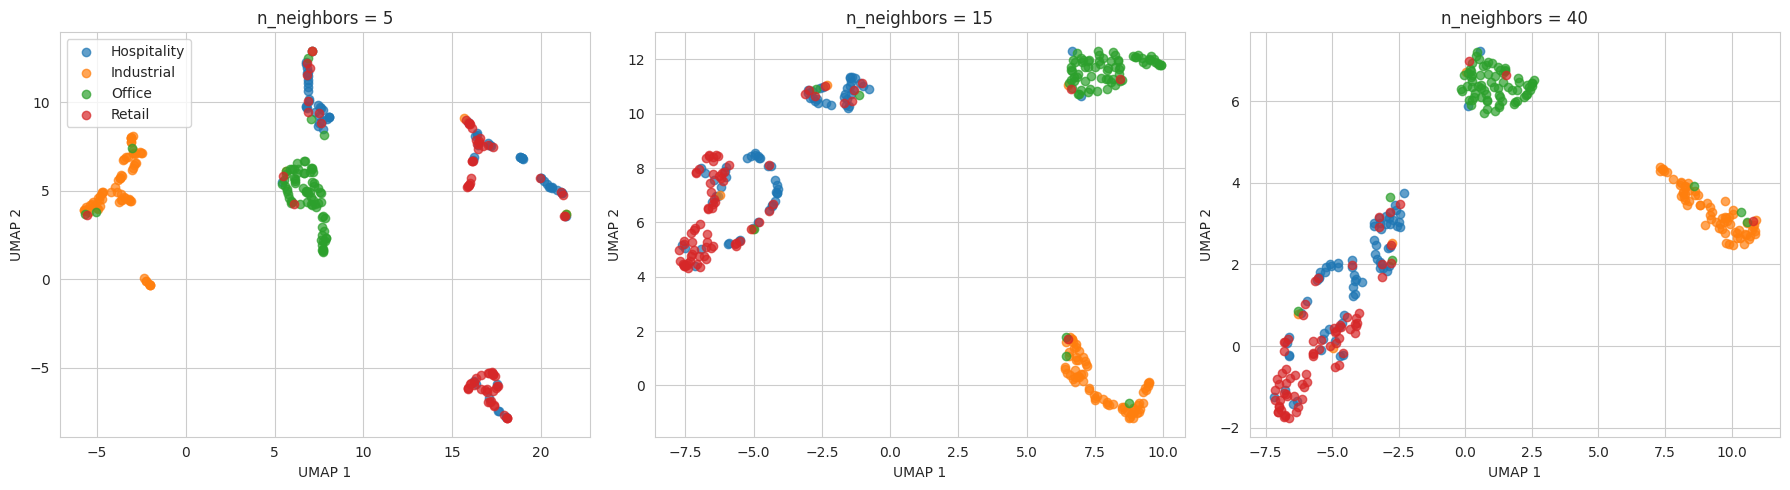

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, n_neighbors in enumerate([5, 15, 40]):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, random_state=RANDOM_STATE)
    embedding = reducer.fit_transform(X_scaled)

    for category, idx in df.groupby('Category').groups.items():
        mask = df.index.isin(idx)
        axes[i].scatter(embedding[mask, 0], embedding[mask, 1], label=category, alpha=0.7)

    axes[i].set_title(f'n_neighbors = {n_neighbors}')
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')

axes[0].legend()
plt.tight_layout()
plt.show()

Summary: Discusses UMAP n_neighbors tuning, noting tighter and more cohesive cluster projections compared to t-SNE.

Summary: Compares PCA, t-SNE, and UMAP features, strengths, and output characteristics.

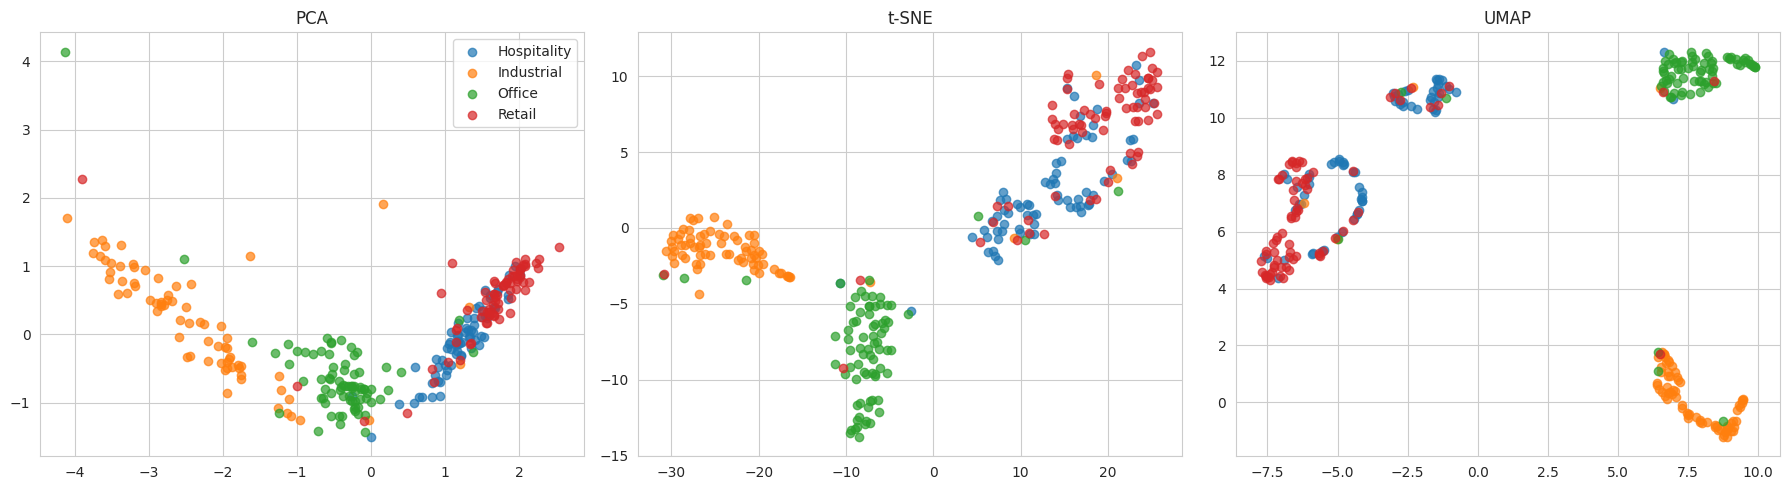

In [51]:
tsne_best = TSNE(n_components=2, perplexity=30, init='pca', random_state=RANDOM_STATE).fit_transform(X_scaled)
umap_best = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

projections = {
    'PCA': (principal_components[:, 0], principal_components[:, 1]),
    't-SNE': (tsne_best[:, 0], tsne_best[:, 1]),
    'UMAP': (umap_best[:, 0], umap_best[:, 1])
}

for ax, (name, (x, y)) in zip(axes, projections.items()):
    for category, idx in df.groupby('Category').groups.items():
        mask = df.index.isin(idx)
        ax.scatter(np.array(x)[mask], np.array(y)[mask], label=category, alpha=0.7)
    ax.set_title(name)

axes[0].legend()
plt.tight_layout()
plt.show()

Summary: Reviews side-by-side projections, comparing linear and non-linear properties in separating business categories.

Summary: Part 3 introduction. Combines spatial segments (HDBSCAN) with business attributes (PCA) for neighborhood profiling, dropping noise first.

In [52]:
clean_df = df[df['HDBSCAN_Cluster'] != -1]
n_dropped = (df['HDBSCAN_Cluster'] == -1).sum()
n_remaining = len(clean_df)
print(f"Dropped noise points: {n_dropped}")
print(f"Remaining points: {n_remaining}")

neighborhood_profile = clean_df.groupby('Neighborhood')[
    ['Floor_Area_sqm', 'Daily_Foot_Traffic', 'Community_Impact_Score', 'Annual_Revenue_k']
].mean()

neighborhood_profile = neighborhood_profile.sort_values('Community_Impact_Score', ascending=False)
print(neighborhood_profile)

Dropped noise points: 17
Remaining points: 279
                       Floor_Area_sqm  Daily_Foot_Traffic  \
Neighborhood                                                
City Centre                205.058824         2032.220588   
Riverside Commons          293.852941         1440.176471   
Unzoned                   2958.285714          944.571429   
Tech Corridor              997.661765          614.426471   
Outer Industrial Park    16130.220588          379.897059   

                       Community_Impact_Score  Annual_Revenue_k  
Neighborhood                                                     
City Centre                         80.647059        468.426471  
Riverside Commons                   75.411765        503.205882  
Unzoned                             59.285714       6003.857143  
Tech Corridor                       42.632353       4650.411765  
Outer Industrial Park               17.470588       8620.455882  


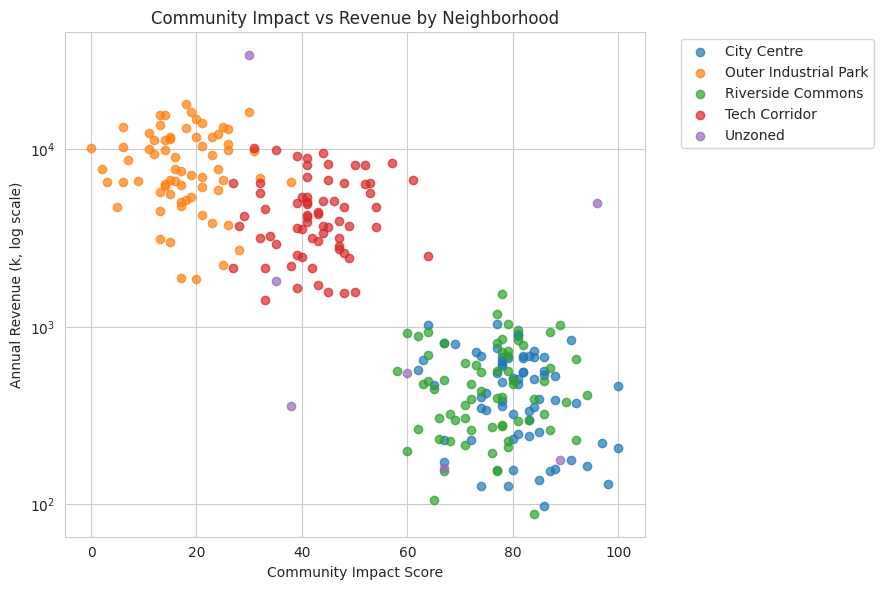

In [53]:
fig, ax = plt.subplots(figsize=(9, 6))

for neighborhood, group in clean_df.groupby('Neighborhood'):
    ax.scatter(group['Community_Impact_Score'], group['Annual_Revenue_k'], label=neighborhood, alpha=0.7)

ax.set_yscale('log')
ax.set_xlabel('Community Impact Score')
ax.set_ylabel('Annual Revenue (k, log scale)')
ax.set_title('Community Impact vs Revenue by Neighborhood')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Summary: Profiles neighborhoods based on community impact vs. revenue trade-off, recommending Retail in City Centre or Tech Corridor office locations.

Summary: Concludes the lab, summarizing findings on spatial clustering and dimensionality reduction methods. Lists practice questions.